# Benchmark Models (SHAR)

In [6]:
import pandas as pd 
import numpy as np
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data Sets/RV_total.csv"
df = pd.read_csv(file_path)

# Convert "Date" column to datetime 
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_convert("Europe/Berlin")
df = df.sort_values("Date").set_index("Date")

df.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_intra_pos,RV_intra_neg,RV_overnight_pos,RV_overnight_neg,RV_overnight,RV_total,RV_total_pos,RV_total_neg,RQ,r_daily,log_RV_total,log_RV_intra
Date,,,,,,,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000066,0.000042,0.000000,0.000001,0.000001,0.000109,0.000066,0.000043,1.898579e-08,0.019734,-9.121878,-9.133686
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000058,0.000071,0.000029,0.000000,0.000029,0.000158,0.000087,0.000071,2.613017e-08,-0.000387,-8.755823,-8.957822
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000032,0.000036,0.000049,0.000000,0.000049,0.000117,0.000081,0.000036,7.450015e-09,0.004685,-9.056151,-9.602531
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000052,0.000057,0.000000,0.000008,0.000008,0.000117,0.000052,0.000065,1.545187e-08,-0.007108,-9.052878,-9.123543
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000053,0.000036,0.000000,0.000007,0.000007,0.000097,0.000053,0.000043,3.748493e-08,0.001214,-9.243673,-9.322462


## 1.4 SHAR Model

SHAR (Semivarance HAR) extends the standard HAR idea by acknowledging that volatility generated by **negative returns ("bad" volatility)** can have a different persistwence and predictive power than volatility generated by **positive returns ("good" volatility)**. Instead of using only yesterday's total realized variance, SHAR splits the daily lag into two components - positive and negative realized semivariance - so the model can estimate **eparate effects** for upside vs. downside moves, while still keeping the usual weekly and monthly HAR persistence terms. 

$$
RV_t
= \beta_0
+ \beta_1^{+} \, RV^{+}_{t-1}
+ \beta_1^{-} \, RV^{-}_{t-1}
+ \beta_2 \, RV^{(w)}_{t-1}
+ \beta_3 \, RV^{(m)}_{t-1}
+ \varepsilon_t,
$$

In [20]:
# =========================
# SHAR Model Construction
# =========================

# Safety procedure
df_shar = df.copy()
df_shar = df_shar.sort_index()

# 1) Base RV series in levels
rv = df_shar["RV_total"]

# 2) SHAR components available at time t

# Daily positive and negative semivariance
df_shar["RV_pos_d"] = df_shar["RV_total_pos"]
df_shar["RV_neg_d"] = df_shar["RV_total_neg"]

# Weekly and monthly HAR components (based on total RV)
df_shar["RV_w"] = rv.rolling(5).mean()     # average RV_{t|t-4}
df_shar["RV_m"] = rv.rolling(22).mean()    # average RV_{t|t-21}

# 3) Target: next day RV
df_shar["RV_target"] = rv.shift(-1)

df_shar.tail()

,Open,Close,log_open,log_close,r_overnight,RV_intra,RV_intra_pos,RV_intra_neg,RV_overnight_pos,RV_overnight_neg,...,RV_total_neg,RQ,r_daily,log_RV_total,log_RV_intra,RV_pos_d,RV_neg_d,RV_w,RV_m,RV_target
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-03 00:00:00+02:00,3186.02,3253.20,8.066528,8.087394,-0.001132,0.000108,0.000066,0.000042,0.000000,0.000001,...,0.000043,1.898579e-08,0.019734,-9.121878,-9.133686,0.000066,0.000043,0.000100,0.000151,0.000158
2020-08-04 00:00:00+02:00,3270.71,3251.94,8.092762,8.087007,0.005368,0.000129,0.000058,0.000071,0.000029,0.000000,...,0.000071,2.613017e-08,-0.000387,-8.755823,-8.957822,0.000087,0.000071,0.000119,0.000155,0.000117
2020-08-05 00:00:00+02:00,3274.81,3267.21,8.094015,8.091692,0.007008,0.000068,0.000032,0.000036,0.000049,0.000000,...,0.000036,7.450015e-09,0.004685,-9.056151,-9.602531,0.000081,0.000036,0.000136,0.000135,0.000117
2020-08-06 00:00:00+02:00,3257.99,3244.07,8.088866,8.084584,-0.002826,0.000109,0.000052,0.000057,0.000000,0.000008,...,0.000065,1.545187e-08,-0.007108,-9.052878,-9.123543,0.000052,0.000065,0.000132,0.000136,0.000097
2020-08-07 00:00:00+02:00,3235.30,3248.01,8.081877,8.085798,-0.002707,0.000089,0.000053,0.000036,0.000000,0.000007,...,0.000043,3.748493e-08,0.001214,-9.243673,-9.322462,0.000053,0.000043,0.000119,0.000132,NaN


In [22]:
# Drop NA to define usable SHAR sample
df_shar = df_shar.dropna(
    subset=["RV_pos_d", "RV_neg_d", "RV_w", "RV_m", "RV_target"]
)

print("First usable date:", df_shar.index.min())
print("Last usable date:", df_shar.index.max())
print("Number of usable observations:", len(df_shar))

First usable date: 1998-03-31 00:00:00+02:00
Last usable date: 2020-08-06 00:00:00+02:00
Number of usable observations: 5689


**Deciding on train, validation, and test splits:**
* Train = 1998 - 2012 (Train includes dot-com + GFC → rich volatility regimes) *~60–65% train*
* Validation = 2013 - 2015 (Validation includes Euro crisis aftershocks) *~15% validation*
* Test = 2016 - 2020 (Test includes calm + COVID shock) *~20–25% test*

In [25]:
# Define split dates
train_end = "2012-12-31"
val_end   = "2015-12-31"

df_train = df_shar.loc[:train_end]
df_val   = df_shar.loc[train_end:val_end]
df_test  = df_shar.loc[val_end:]

# Remove boundary overlap (same logic as before)
df_val  = df_val.iloc[1:]
df_test = df_test.iloc[1:]

print("Train observations:", len(df_train))
print("Validation observations:", len(df_val))
print("Test observations:", len(df_test))

print("\nTrain period:", df_train.index.min(), "to", df_train.index.max())
print("Validation period:", df_val.index.min(), "to", df_val.index.max())
print("Test period:", df_test.index.min(), "to", df_test.index.max())

Train observations: 3745
Validation observations: 768
Test observations: 1176

Train period: 1998-03-31 00:00:00+02:00 to 2012-12-31 00:00:00+01:00
Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00


#### HARQ on Training set

In [28]:
import statsmodels.api as sm

# Regressors and target (training only)
X_train = df_train[["RV_pos_d", "RV_neg_d", "RV_w", "RV_m"]]
y_train = df_train["RV_target"]

# Add intercept
X_train = sm.add_constant(X_train)

# Estimate OLS (SHAR)
shar_model = sm.OLS(y_train, X_train).fit()
print(shar_model.summary())

                            OLS Regression Results                            
Dep. Variable:              RV_target   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.579
Method:                 Least Squares   F-statistic:                     1287.
Date:                Fri, 20 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:24:38   Log-Likelihood:                 27205.
No. Observations:                3745   AIC:                        -5.440e+04
Df Residuals:                    3740   BIC:                        -5.437e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.597e-05   3.67e-06      4.349      0.0

In [30]:
from tqdm import tqdm

# Validation + Test evaluation set
df_eval = pd.concat([df_val, df_test])

predictions = []
actuals = []
dates = []

for current_date in tqdm(df_eval.index):

    # Expanding window: all rows strictly before current_date
    df_expanding = df_shar.loc[:current_date].iloc[:-1]

    X = df_expanding[["RV_pos_d", "RV_neg_d", "RV_w", "RV_m"]]
    y = df_expanding["RV_target"]

    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit()

    # Forecast row
    X_fore = df_shar.loc[[current_date], ["RV_pos_d", "RV_neg_d", "RV_w", "RV_m"]]
    X_fore = sm.add_constant(X_fore, has_constant="add")
    X_fore = X_fore.reindex(columns=X.columns)

    rv_forecast = float(model.predict(X_fore).iloc[0])
    rv_actual   = float(df_shar.loc[current_date, "RV_target"])

    predictions.append(rv_forecast)
    actuals.append(rv_actual)
    dates.append(current_date)

df_forecast_shar = pd.DataFrame({"Forecast": predictions, "Actual": actuals}, index=dates)

print(df_forecast_shar.head())
print("\nForecast df shape:", df_forecast_shar.shape)


100%|██████████████████████████████████████| 1944/1944 [00:03<00:00, 576.74it/s]

                           Forecast    Actual
2013-01-02 00:00:00+01:00  0.000096  0.000027
2013-01-03 00:00:00+01:00  0.000057  0.000032
2013-01-04 00:00:00+01:00  0.000060  0.000028
2013-01-07 00:00:00+01:00  0.000057  0.000027
2013-01-08 00:00:00+01:00  0.000059  0.000030

Forecast df shape: (1944, 2)


In [36]:
# Validation and test ranges (from your split dataframes)
val_start, val_end = df_val.index.min(), df_val.index.max()
test_start, test_end = df_test.index.min(), df_test.index.max()

# Slice SHAR forecasts into validation and test
df_forecast_val = df_forecast_shar.loc[val_start:val_end]
df_forecast_test = df_forecast_shar.loc[test_start:test_end]

# Compute MSE
mse_val = np.mean((df_forecast_val["Actual"] - df_forecast_val["Forecast"])**2)
mse_test = np.mean((df_forecast_test["Actual"] - df_forecast_test["Forecast"])**2)

print(f"Validation period: {val_start} to {val_end} | n = {len(df_forecast_val)}")
print(f"Test period: {test_start} to {test_end} | n = {len(df_forecast_test)}")

print("\nValidation MSE (SHAR):", mse_val)
print("Test MSE (SHAR):", mse_test)

Validation period: 2013-01-02 00:00:00+01:00 to 2015-12-31 00:00:00+01:00 | n = 768
Test period: 2016-01-04 00:00:00+01:00 to 2020-08-06 00:00:00+02:00 | n = 1176

Validation MSE (SHAR): 1.1519029692131893e-08
Test MSE (SHAR): 2.2678865602080142e-08


Test MSE is double the size of Validation MSE, which is economically inuitive as the test period includes the 2018 volatility spike and the 2020 COVID shock. Volatility forecasting models struggle more during crisis regimes.

Hom much better HAR is than simply forecasting historical mean: 
$$
R^2_{\text{OOS}}
= 1
- \frac{\sum \left( RV_{t+1} - \widehat{RV}_{t+1} \right)^2}
       {\sum \left( RV_{t+1} - \overline{RV} \right)^2}
$$

#### Plot performance during Test period

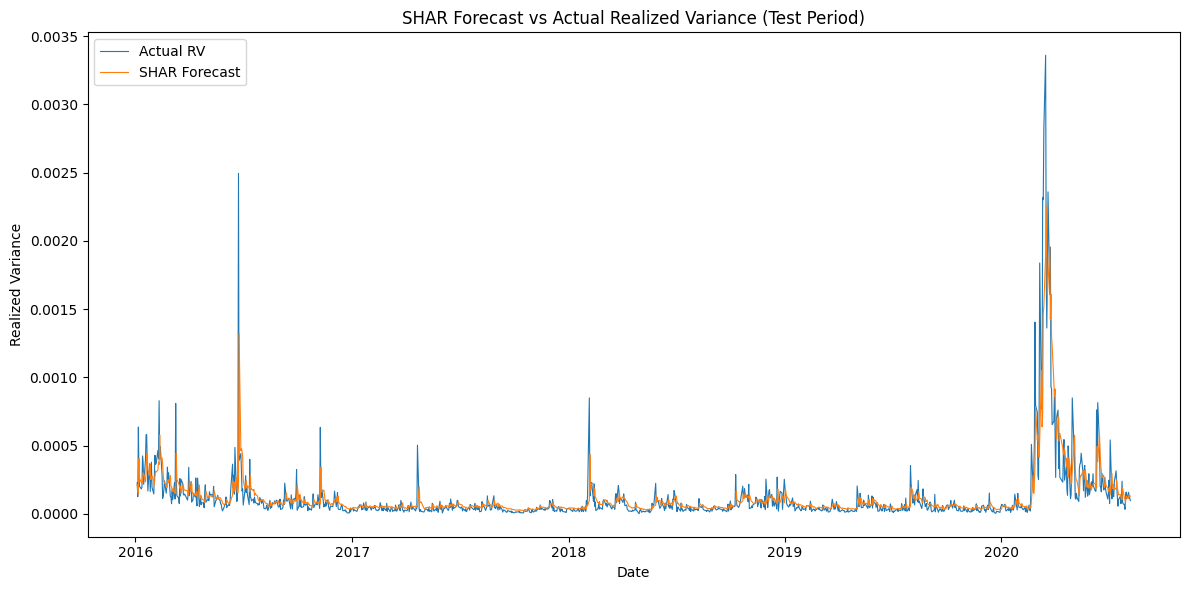

In [39]:
import matplotlib.pyplot as plt

# Select SHAR forecasts during test period
df_plot = df_forecast_shar.loc[
    df_test.index.min():df_test.index.max()
].copy()

plt.figure(figsize=(12,6))
plt.plot(df_plot.index, df_plot["Actual"], 
         label="Actual RV", 
         linewidth=0.8)

plt.plot(df_plot.index, df_plot["Forecast"], 
         label="SHAR Forecast", 
         linewidth=0.8)

plt.title("SHAR Forecast vs Actual Realized Variance (Test Period)")
plt.xlabel("Date")
plt.ylabel("Realized Variance")

plt.legend()
plt.tight_layout()
plt.show()

In [41]:
mean_train = df_train["RV_target"].mean()

df_forecast_val = df_forecast_shar.loc[val_start:val_end]
df_forecast_test = df_forecast_shar.loc[test_start:test_end]

# Validation
sse_val = np.sum((df_forecast_val["Actual"] - df_forecast_val["Forecast"])**2)
sse_val_bench = np.sum((df_forecast_val["Actual"] - mean_train)**2)
r2_oos_val = 1 - (sse_val / sse_val_bench)

# Test
sse_test = np.sum((df_forecast_test["Actual"] - df_forecast_test["Forecast"])**2)
sse_test_bench = np.sum((df_forecast_test["Actual"] - mean_train)**2)
r2_oos_test = 1 - (sse_test / sse_test_bench)

print("Out-of-sample R^2 (Validation, SHAR):", r2_oos_val)
print("Out-of-sample R^2 (Test, SHAR):", r2_oos_test)

Out-of-sample R^2 (Validation, SHAR): 0.3993355711367349
Out-of-sample R^2 (Test, SHAR): 0.6608200471308485


* $R^2_{\text{OOS}} > 0$ --> model beats mean forecast
* $R^2_{\text{OOS}} = 0$ --> same as mean forecast
* $R^2_{\text{OOS}} < 0$ --> wore than mean forecast

## Performance during COVID

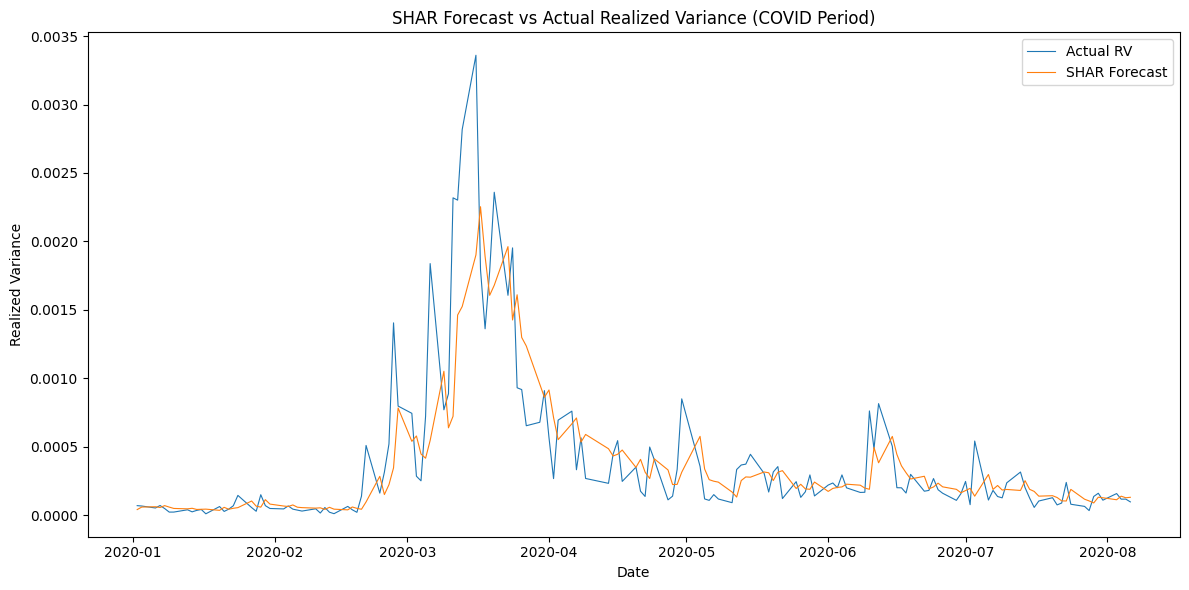

In [46]:
df_covid = df_forecast_shar.loc["2020-01-01":].copy()

plt.figure(figsize=(12,6))
plt.plot(df_covid.index, df_covid["Actual"], 
         label="Actual RV", 
         linewidth=0.8)

plt.plot(df_covid.index, df_covid["Forecast"], 
         label="SHAR Forecast", 
         linewidth=0.8)

plt.title("SHAR Forecast vs Actual Realized Variance (COVID Period)")
plt.xlabel("Date")
plt.ylabel("Realized Variance")

plt.legend()
plt.tight_layout()
plt.show()